# Problem Set II - QPROG  

## Implementing the Bernstein Vazirani Protocol in Qiskit  

**Group:** Group T  
**Students:** Erik Lind Gou-Said and Jady Pâmella Barbacena da Silva  
**Course:** QPROG - Quantum Programming  
**Assignment:** Problem Set II - Implementing the Bernstein Vazirani Protocol in Qiskit  
**Instructor:** Mateus de Oliveira Oliveira  
**Department:** Department of Computer and Systems Sciences, Stockholm University  

This notebook implements the Bernstein Vazirani protocol in Qiskit, including:  
- An inner product oracle implemented with CNOT gates  
- A layer of Hadamard gates on all qubits  
- A function that builds the complete Bernstein Vazirani circuit for any secret bit string  
- Simulation of the circuit using a local simulator, showing that the measurement result reveals the secret string

## Environment Setup

Install required packages for this notebook.

In [43]:
# Install required packages
%pip install qiskit==2.2.3
%pip install qiskit-aer==0.17.2
%pip install qiskit-ibm-runtime==0.43.1
%pip install matplotlib





Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Bernstein-Vazirani Algorithm Implementation

This notebook implements the Bernstein-Vazirani algorithm in Qiskit, which discovers a hidden binary string in a single quantum query.

In [44]:
# Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Task 1: Inner Product Oracle

Implement the oracle function that encodes the hidden string `a` as a quantum operation.

In [45]:
def inner_product(circuit, a):
    """
    Apply the oracle for the inner product function f(x) = a·x mod 2
    
    Args:
        circuit: QuantumCircuit with n+1 qubits (n input qubits + 1 ancilla)
        a: Binary string representing the hidden string
    """
    n = len(a)
    
    # Reverse the string to match qubit ordering
    # q0 is least significant, a[0] is most significant
    a_reversed = a[::-1]
    
    # Apply CNOT gates where a_reversed[i] = '1'
    for i in range(n):
        if a_reversed[i] == '1':
            circuit.cx(i, n)  # CNOT from qubit i to ancilla (last qubit)
    
    # Add barrier to separate this block
    circuit.barrier()

In [46]:
# Task 1 Test
def test_circuit_1():
    a = "01101"
    n = len(a)
    circuit = QuantumCircuit(n+1, 0)
    inner_product(circuit, a)
    print(circuit)

test_circuit_1()

                     ░ 
q_0: ──■─────────────░─
       │             ░ 
q_1: ──┼─────────────░─
       │             ░ 
q_2: ──┼────■────────░─
       │    │        ░ 
q_3: ──┼────┼────■───░─
       │    │    │   ░ 
q_4: ──┼────┼────┼───░─
     ┌─┴─┐┌─┴─┐┌─┴─┐ ░ 
q_5: ┤ X ├┤ X ├┤ X ├─░─
     └───┘└───┘└───┘ ░ 


## Task 2: Hadamard Gates

Apply Hadamard gates to all qubits to create superposition.

In [47]:
def hadamards(circuit):
    """
    Apply a layer of Hadamard gates to all qubits in the circuit.
    """
    circuit.barrier()
    num_qubits = circuit.num_qubits
    for qubit in range(num_qubits):
        circuit.h(qubit)
    circuit.barrier()

In [48]:
# Test Task 2
circuit = QuantumCircuit(5, 0)
hadamards(circuit)
print(circuit)

      ░ ┌───┐ ░ 
q_0: ─░─┤ H ├─░─
      ░ ├───┤ ░ 
q_1: ─░─┤ H ├─░─
      ░ ├───┤ ░ 
q_2: ─░─┤ H ├─░─
      ░ ├───┤ ░ 
q_3: ─░─┤ H ├─░─
      ░ ├───┤ ░ 
q_4: ─░─┤ H ├─░─
      ░ └───┘ ░ 


## Task 3: Complete Bernstein-Vazirani Algorithm

Combine the oracle and Hadamard gates to implement the full algorithm.

In [49]:
def bernstein_vazirani(a):
    """
    Create a complete Bernstein-Vazirani circuit to discover the hidden string a
    
    Args:
        a: Binary string to be discovered
        
    Returns:
        QuantumCircuit implementing the Bernstein-Vazirani algorithm
    """
    n = len(a)
    
    # Step 1: Create circuit with n+1 qubits and n classical bits
    circuit = QuantumCircuit(n+1, n)
    
    # Step 2: Initialize ancilla qubit to |1⟩
    circuit.x(n)
    circuit.barrier()
    
    # Step 3: Apply Hadamard gates to all qubits
    hadamards(circuit)
    circuit.barrier()
    
    # Step 4: Apply the oracle (inner product circuit)
    inner_product(circuit, a)
    
    # Step 5: Apply Hadamard gates to input qubits only (not ancilla)
    for i in range(n):
        circuit.h(i)
    circuit.barrier()
    
    # Step 6: Measure the input qubits
    for i in range(n):
        circuit.measure(i, i)
    
    return circuit

In [50]:
# Task 3 Test
def test_circuit_3():
    a = "01101"
    circuit = bernstein_vazirani(a)
    print(circuit)

test_circuit_3()

           ░  ░ ┌───┐ ░  ░                 ░ ┌───┐ ░ ┌─┐            
q_0: ──────░──░─┤ H ├─░──░───■─────────────░─┤ H ├─░─┤M├────────────
           ░  ░ ├───┤ ░  ░   │             ░ ├───┤ ░ └╥┘┌─┐         
q_1: ──────░──░─┤ H ├─░──░───┼─────────────░─┤ H ├─░──╫─┤M├─────────
           ░  ░ ├───┤ ░  ░   │             ░ ├───┤ ░  ║ └╥┘┌─┐      
q_2: ──────░──░─┤ H ├─░──░───┼────■────────░─┤ H ├─░──╫──╫─┤M├──────
           ░  ░ ├───┤ ░  ░   │    │        ░ ├───┤ ░  ║  ║ └╥┘┌─┐   
q_3: ──────░──░─┤ H ├─░──░───┼────┼────■───░─┤ H ├─░──╫──╫──╫─┤M├───
           ░  ░ ├───┤ ░  ░   │    │    │   ░ ├───┤ ░  ║  ║  ║ └╥┘┌─┐
q_4: ──────░──░─┤ H ├─░──░───┼────┼────┼───░─┤ H ├─░──╫──╫──╫──╫─┤M├
     ┌───┐ ░  ░ ├───┤ ░  ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ░  ║  ║  ║  ║ └╥┘
q_5: ┤ X ├─░──░─┤ H ├─░──░─┤ X ├┤ X ├┤ X ├─░───────░──╫──╫──╫──╫──╫─
     └───┘ ░  ░ └───┘ ░  ░ └───┘└───┘└───┘ ░       ░  ║  ║  ║  ║  ║ 
c: 5/═════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                  

## Simulation and Results

Execute the circuit using AerSimulator to verify the algorithm discovers the hidden string.

In [51]:
# Run the Bernstein-Vazirani algorithm
a = "01101"
circuit = bernstein_vazirani(a)

# Use AerSimulator
simulator = AerSimulator()

# Transpile and run
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

# Get counts
counts = result.get_counts()
print(f"Hidden string: {a}")
print(f"Measurement results: {counts}")

# The result should match the hidden string
measured_string = max(counts, key=counts.get)
print(f"Discovered string: {measured_string}")
print(f"Match: {a == measured_string}")

Hidden string: 01101
Measurement results: {'01101': 1024}
Discovered string: 01101
Match: True


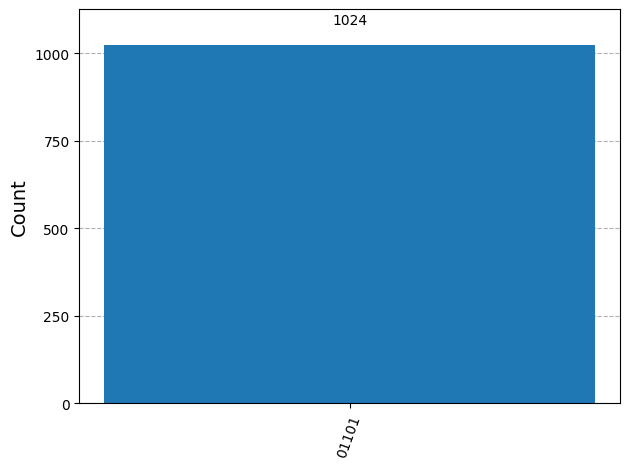

In [52]:
# Visualize results
plot_histogram(counts)

In [55]:
# Show probability distribution in the format {13: 0.9999999999999998}
from qiskit.quantum_info import Statevector

# Create circuit without measurements
n = len(a)
circuit_no_measure = QuantumCircuit(n+1)
circuit_no_measure.x(n)
hadamards(circuit_no_measure)
inner_product(circuit_no_measure, a)
for i in range(n):
    circuit_no_measure.h(i)

# Get statevector and probabilities
state = Statevector.from_instruction(circuit_no_measure)
probs = state.probabilities_dict()

# Convert binary keys to decimal and filter non-zero
result = {int(k, 2): v for k, v in probs.items() if v > 1e-10}
print(result)

{13: np.float64(0.4999999999999991), 45: np.float64(0.4999999999999991)}


## Additional Tests

Test the algorithm with different hidden strings, including strings with leading zeros.

In [53]:
# Test with multiple hidden strings, including those with leading zeros
test_strings = ["1010", "1111", "0000", "0000101", "10101010"]

for test_a in test_strings:
    circuit = bernstein_vazirani(test_a)
    compiled_circuit = transpile(circuit, simulator)
    job = simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    counts = result.get_counts()
    
    measured_string = max(counts, key=counts.get)
    
    print(f"Hidden: {test_a} | Discovered: {measured_string} | Match: {test_a == measured_string}")

Hidden: 1010 | Discovered: 1010 | Match: True
Hidden: 1111 | Discovered: 1111 | Match: True
Hidden: 0000 | Discovered: 0000 | Match: True
Hidden: 0000101 | Discovered: 0000101 | Match: True
Hidden: 0000 | Discovered: 0000 | Match: True
Hidden: 0000101 | Discovered: 0000101 | Match: True
Hidden: 10101010 | Discovered: 10101010 | Match: True
Hidden: 10101010 | Discovered: 10101010 | Match: True
